In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# ── PATHS ─────────────────────────────────────────────────────────────
PROJECT_DIR = '/content/drive/MyDrive/M3 Project'
CSV_DIR     = f'{PROJECT_DIR}/collected data'
SISFALL_NPZ = '/content/drive/MyDrive/dataset_exp4_v4_final.npz'
BASE_KERAS  = f'/content/drive/MyDrive/M3 Project/final_cnn_v2.keras'
OUT_TFLITE  = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_v2_finetuned.tflite'
OUT_HEADER  = f'{PROJECT_DIR}/cnn_model_two_stage/final_cnn_v2_finetuned.h'
OUT_GATE_H  = f'{PROJECT_DIR}/cnn_model_two_stage/gate_model_v2.h'

# Auto-fix: if .keras missing but .zip or unzipped folder exists, repack
if not os.path.exists(BASE_KERAS):
    cand_zip = BASE_KERAS.replace('.keras', '.zip')
    cand_dir = BASE_KERAS.replace('.keras', '')
    if os.path.exists(cand_zip):
        import shutil; shutil.copy(cand_zip, BASE_KERAS)
        print(f'Renamed {cand_zip} -> {BASE_KERAS}')
    elif os.path.isdir(cand_dir) and all(
            os.path.exists(os.path.join(cand_dir, n))
            for n in ['metadata.json','config.json','model.weights.h5']):
        import zipfile
        with zipfile.ZipFile(BASE_KERAS, 'w', zipfile.ZIP_STORED) as zf:
            for n in ['metadata.json','config.json','model.weights.h5']:
                zf.write(os.path.join(cand_dir, n), n)
        print(f'Repacked {cand_dir} -> {BASE_KERAS}')
    else:
        # Search for the file anywhere under PROJECT_DIR
        hits = glob.glob(f'{PROJECT_DIR}/**/final_cnn_v2*', recursive=True)
        raise FileNotFoundError(
            f'BASE_KERAS not found at {BASE_KERAS}. '
            f'Candidates found:\n  ' + '\n  '.join(hits))

assert os.path.exists(CSV_DIR),     f'CSV folder not found: {CSV_DIR}'
assert os.path.exists(SISFALL_NPZ), f'SisFall npz not found: {SISFALL_NPZ}'
assert os.path.exists(BASE_KERAS),  f'Base Keras model not found: {BASE_KERAS}'
print('All paths OK')

# ── CONSTANTS ─────────────────────────────────────────────────────────
WIN_SAMPLES, STRIDE, FALL_PRE, FALL_POST = 50, 20, 25, 25
HARD_THRESH, EASY_THRESH, MAX_HARD, MAX_EASY = 1.569, 1.072, 3, 5
STILL_MEAN, MIN_STILL = 1.25, 150
GATE_THRESHOLD = 0.58
TRIM_SAMPLES = 100
rng = np.random.RandomState(42)

EXCLUDE = {'session1/F01_01.csv','session1/F01_05.csv','session1/F02_01.csv',
           'session1/F02_03.csv','session1/F02_05.csv','session2/F02_01.csv'}

# ── CSV LOADER ────────────────────────────────────────────────────────
def load_csv(filepath):
    cols = ['t_ms','ax_g','ay_g','az_g','gx_dps','gy_dps','gz_dps']
    header_line = None
    with open(filepath, 'rb') as f:
        for i, line in enumerate(f):
            if line.strip().startswith(b't_ms'):
                header_line = i; break
    if header_line is None: return None, None
    try:
        df = pd.read_csv(filepath, skiprows=header_line, on_bad_lines='skip')
        for c in cols: df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna(subset=cols)[['ax_g','ay_g','az_g','gx_dps','gy_dps','gz_dps']]
    except Exception as e:
        print(f'  Parse error: {e}'); return None, None
    df = df.iloc[TRIM_SAMPLES:-TRIM_SAMPLES]
    if len(df) < WIN_SAMPLES: return None, None
    return (df[['ax_g','ay_g','az_g']].values.astype(np.float32),
            df[['gx_dps','gy_dps','gz_dps']].values.astype(np.float32))

def smv(a): return np.sqrt(np.sum(a**2, axis=1))

# ── LOAD CSVs ─────────────────────────────────────────────────────────
csv_files = sorted(glob.glob(os.path.join(CSV_DIR, '**', '*.csv'), recursive=True))
print(f'Found {len(csv_files)} CSV files')

fall_trials, adl_trials, skipped = [], [], []
for fp in csv_files:
    fname    = os.path.basename(fp)
    rel_path = os.path.relpath(fp, CSV_DIR)
    if rel_path in EXCLUDE: skipped.append(rel_path); continue
    pfx = fname[0].upper()
    if   pfx == 'F': label = 1
    elif pfx == 'D': label = 0
    else: skipped.append(fname); continue
    accel, gyro = load_csv(fp)
    if accel is None: skipped.append(fname); continue
    trial = {'filename':fname,'label':label,'accel':accel,'gyro':gyro,
             'a_smv':smv(accel),'g_smv':smv(gyro)}
    (fall_trials if label==1 else adl_trials).append(trial)
print(f'Falls: {len(fall_trials)}  ADLs: {len(adl_trials)}  Skipped: {len(skipped)}')

# ── WINDOWING ─────────────────────────────────────────────────────────
def detect_impact(a_smv, g_smv):
    n = len(a_smv); pk = int(np.argmax(a_smv)); ap = float(a_smv[pk])
    gs = max(0, pk-100); ge = min(n, pk+100); gp = float(g_smv[gs:ge].max())
    if not (ap >= 1.4 and (gp >= 90.0 or ap >= 4.0)): return None
    ss = -1
    for i in range(pk+1, n-MIN_STILL):
        if a_smv[i:i+MIN_STILL].mean() < STILL_MEAN: ss = i; break
    if ss == -1: return None
    ch = min(ss+MIN_STILL, n)
    if ch < n and float(a_smv[ch:].max()) > 2.5: return None
    return pk

def get_fall_window(trial):
    pk = detect_impact(trial['a_smv'], trial['g_smv'])
    if pk is None: return None
    raw6 = np.concatenate([trial['accel'], trial['gyro']], axis=1)
    s,e = pk-FALL_PRE, pk+FALL_POST
    if s<0 or e>len(raw6): return None
    return raw6[s:e].astype(np.float32)

def get_adl_windows(trial):
    raw6 = np.concatenate([trial['accel'], trial['gyro']], axis=1)
    a = trial['a_smv']; hard, easy = [], []
    for w in range(0, len(raw6)-WIN_SAMPLES+1, STRIDE):
        pk = float(a[w:w+WIN_SAMPLES].max()); win = raw6[w:w+WIN_SAMPLES]
        if   pk >= HARD_THRESH: hard.append((pk, win))
        elif pk <  EASY_THRESH: easy.append(win)
    hard.sort(key=lambda x: -x[0])
    hw = [w for _,w in hard[:MAX_HARD]]
    if len(easy) > MAX_EASY:
        easy = [easy[i] for i in rng.choice(len(easy), MAX_EASY, replace=False)]
    return hw + easy

windows, labels, fall_skipped = [], [], []
for t in fall_trials:
    w = get_fall_window(t)
    if w is not None: windows.append(w); labels.append(1)
    else: fall_skipped.append(t['filename'])
for t in adl_trials:
    for w in get_adl_windows(t): windows.append(w); labels.append(0)
X = np.array(windows, dtype=np.float32)
y = np.array(labels,  dtype=np.int32)
n_total = len(y)
print(f'Windows: total={n_total}  falls={int(y.sum())}  adls={int((y==0).sum())}')
if fall_skipped: print(f'Falls without impact detected: {fall_skipped}')

# ── 20 FEATURES ───────────────────────────────────────────────────────
FEATURE_NAMES_20 = [
    'accel_x_max','accel_y_max','accel_z_max','accel_x_std','accel_y_std','accel_z_std',
    'accel_x_peak2peak','accel_y_peak2peak','accel_z_peak2peak','accel_y_mean_jerk',
    'accel_magnitude_sq_mean','gyro_magnitude_sq_mean',
    'accel_signal_magnitude_area','gyro_signal_magnitude_area',
    'accel_svm_rms','accel_3d_peak2peak','accel_3d_std',
    'accel_svm_max','accel_svm_std','gyro_magnitude_std']

def extract_20(window):
    wx,wy,wz   = [window[:,i].astype(np.float64) for i in range(3)]
    wxg,wyg,wzg= [window[:,i].astype(np.float64) for i in range(3,6)]
    f = [np.max(wx), np.max(wy), np.max(wz),
         np.std(wx), np.std(wy), np.std(wz),
         np.max(wx)-np.min(wx), np.max(wy)-np.min(wy), np.max(wz)-np.min(wz),
         np.mean(np.abs(np.diff(wy))),
         np.mean(wx**2+wy**2+wz**2), np.mean(wxg**2+wyg**2+wzg**2),
         np.mean(np.abs(wx)+np.abs(wy)+np.abs(wz)),
         np.mean(np.abs(wxg)+np.abs(wyg)+np.abs(wzg))]
    svm = np.sqrt(wx**2+wy**2+wz**2)
    f += [np.sqrt(np.mean(svm**2)),
          np.sqrt((np.max(wx)-np.min(wx))**2+(np.max(wy)-np.min(wy))**2+(np.max(wz)-np.min(wz))**2),
          np.sqrt(np.std(wx)**2+np.std(wy)**2+np.std(wz)**2)]
    gmag = np.sqrt(wxg**2+wyg**2+wzg**2)
    f += [np.max(svm), np.std(svm), np.std(gmag)]
    return np.array(f, dtype=np.float32)

X_feat = np.nan_to_num(np.array([extract_20(w) for w in X], dtype=np.float32))
print(f'Features: {X_feat.shape}')

# ── BASE MODEL + TFLITE ───────────────────────────────────────────────
base_model = keras.models.load_model(BASE_KERAS)
assert tuple(base_model.input_shape)[1:] == (50, 6)
print(f'Base model loaded — {base_model.count_params()} params')

conv = tf.lite.TFLiteConverter.from_keras_model(base_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
base_tflite_bytes = conv.convert()
base_interp = tf.lite.Interpreter(model_content=base_tflite_bytes)
base_interp.allocate_tensors()
base_in, base_out = base_interp.get_input_details(), base_interp.get_output_details()
BASE_IN_SHAPE = tuple(base_in[0]['shape'])

def cnn_predict(interp, ind, outd, shape, ws):
    probs = []
    for w in ws:
        interp.set_tensor(ind[0]['index'], w.reshape(shape).astype(np.float32))
        interp.invoke()
        probs.append(float(interp.get_tensor(outd[0]['index']).flatten()[0]))
    return np.array(probs)

# ── ORIGINAL GATE (hardcoded) ─────────────────────────────────────────
SCALER_MEANS = np.array([
    0.42971454273754756, -0.2887337536218261, 0.33653926570932496,
    0.17680961572224266, 0.27045762159952963, 0.19510111703047683,
    0.8927497124657171, 1.2479464799168363, 0.9444061794988057,
    0.07834210888735628, 1.574355499439405, 6795.9364123993255,
    1.4019766041823933, 58.42353162687036, 1.1817498617464173,
    1.921234756391909, 0.4027520253407969, 2.120018342817862,
    0.31212664115634287, 22.0291616120648], dtype=np.float64)
SCALER_STDS = np.array([
    1.0906016746100955, 1.1364981259988605, 0.9329609302951114,
    0.3588053383909056, 0.4427257569038268, 0.3272144758746891,
    1.9249997433888513, 2.1519916902413607, 1.7374088172676299,
    0.1442703293909912, 1.4480788079880127, 17613.298448316054,
    0.4145862102413671, 85.03158948616705, 0.4216903653073832,
    3.303091607734358, 0.6419352746416279, 2.094810274411141,
    0.5143170046182082, 34.58962470467294], dtype=np.float64)

orig_scaler = StandardScaler()
orig_scaler.mean_ = SCALER_MEANS; orig_scaler.scale_ = SCALER_STDS
orig_scaler.var_ = SCALER_STDS**2; orig_scaler.n_features_in_ = 20
orig_scaler.n_samples_seen_ = 11303

RFE_FEATURE_NAMES   = ['gyro_signal_magnitude_area','accel_y_max',
                       'accel_y_mean_jerk','accel_svm_max','accel_z_std']
RFE_FEATURE_INDICES = [FEATURE_NAMES_20.index(n) for n in RFE_FEATURE_NAMES]

orig_gate = LogisticRegression()
orig_gate.classes_ = np.array([0,1])
orig_gate.intercept_ = np.array([-0.614884350201382])
orig_gate.coef_ = np.array([[1.0181210950729982, 0.32774068140451756,
                              0.0, 0.05188830974505934, 0.0]])
orig_gate.n_features_in_ = 5

# ── STEP 1: CNN THRESHOLD SWEEP ───────────────────────────────────────
X_rfe = orig_scaler.transform(X_feat.astype(np.float64))[:, RFE_FEATURE_INDICES]
gate_probs = orig_gate.predict_proba(X_rfe)[:,1]
passed_idx = np.where(gate_probs >= GATE_THRESHOLD)[0]
print(f'Original gate passes {len(passed_idx)}/{n_total}')

base_probs_passed = cnn_predict(base_interp, base_in, base_out, BASE_IN_SHAPE, X[passed_idx])
base_probs_full = np.zeros(n_total); base_probs_full[passed_idx] = base_probs_passed

def sweep(probs_full, y, lo=0.10, hi=0.95, step=0.01):
    rows = []
    for t in np.arange(lo, hi, step):
        pred = (probs_full >= t).astype(int)
        tn,fp,fn,tp = confusion_matrix(y, pred).ravel()
        sens = tp/(tp+fn) if (tp+fn)>0 else 0
        spec = tn/(tn+fp) if (tn+fp)>0 else 0
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
        rows.append({'threshold':round(t,2),'sensitivity':sens,'specificity':spec,
                     'precision':prec,'accuracy':(tp+tn)/(tp+tn+fp+fn),'f1':f1,
                     'tp':tp,'fn':fn,'fp':fp,'tn':tn})
    return pd.DataFrame(rows)

step1_df = sweep(base_probs_full, y)
valid = step1_df[step1_df['sensitivity'] >= 0.95]
if len(valid)==0: valid = step1_df[step1_df['sensitivity'] >= 0.90]
best1 = valid.loc[valid['f1'].idxmax()]
STEP1_THRESH = float(best1['threshold'])
print(f'\nStep 1 threshold: {STEP1_THRESH}  '
      f'sens={best1["sensitivity"]:.4f}  spec={best1["specificity"]:.4f}  '
      f'prec={best1["precision"]:.4f}  f1={best1["f1"]:.4f}  '
      f'TP={int(best1["tp"])} FP={int(best1["fp"])} FN={int(best1["fn"])} TN={int(best1["tn"])}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All paths OK
Found 99 CSV files
Falls: 32  ADLs: 60  Skipped: 7
Windows: total=408  falls=32  adls=376
Features: (408, 20)
Base model loaded — 345 params
Saved artifact at '/tmp/tmpgqk4uhfd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133663428069136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428072400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428073168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428071248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428071632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428070288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428073936: T

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Loading SisFall...
SisFall: (11303, 50, 6)  falls=1241  adls=10062
Extracting features from SisFall...
New gate threshold: 0.82  passes 68/408  falls=31/32  fp=37
Step 2: sens=0.9688  spec=0.9016  prec=0.4559  fp=37
Augmented falls: 32 -> 160 (5x)
Fine-tune set: (11839, 50, 6)  falls=1401  adls=10438
Class weight: {0: 1.0, 1: 7.5}
Fine-tuning...
Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9463 - loss: 0.2952 - val_accuracy: 0.9611 - val_loss: 0.1106 - learning_rate: 1.0000e-04
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9490 - loss: 0.2414 - val_accuracy: 0.9657 - val_loss: 0.0999 - learning_rate: 1.0000e-04
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9492 - loss: 0.2311 - val_accuracy: 0.9730 - val_loss: 0.0834 - learning_rate: 1.0000e-04
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9510 - loss: 0.2117 - val_accuracy: 0.9741 - val_loss: 0.0795 - learning_rate: 1.0000e-04
Epoch 5/50
315/315 ━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


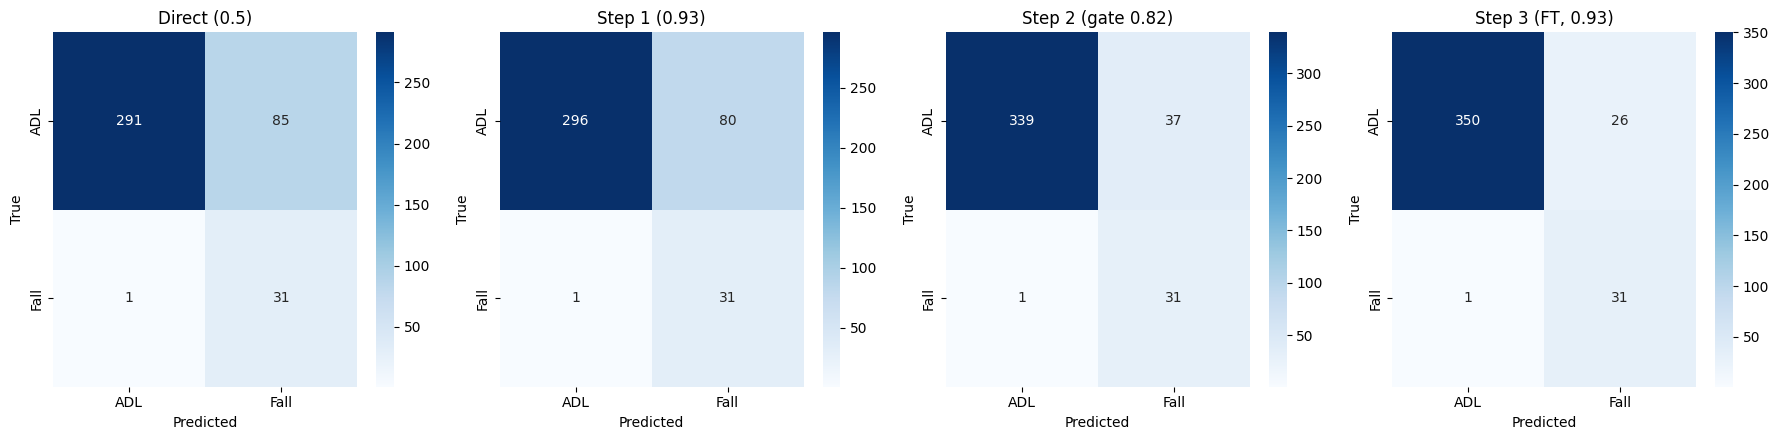

In [9]:
# ── ENSURE OUTPUT DIR EXISTS ──────────────────────────────────────────
os.makedirs(os.path.dirname(OUT_TFLITE), exist_ok=True)

# ── STEP 2: GATE RETRAIN ──────────────────────────────────────────────
print('Loading SisFall...')
sf = np.load(SISFALL_NPZ, allow_pickle=True)
X_sf, y_sf = sf['X_train'].astype(np.float32), sf['y_train'].astype(np.int32)
print(f'SisFall: {X_sf.shape}  falls={y_sf.sum()}  adls={(y_sf==0).sum()}')

print('Extracting features from SisFall...')
X_sf_feat = np.nan_to_num(np.array([extract_20(w) for w in X_sf], dtype=np.float32))

X_comb = np.vstack([X_sf_feat, X_feat])
y_comb = np.concatenate([y_sf, y])
new_scaler = StandardScaler()
X_comb_scaled = new_scaler.fit_transform(X_comb.astype(np.float64))
X_col_scaled  = new_scaler.transform(X_feat.astype(np.float64))
X_comb_rfe = X_comb_scaled[:, RFE_FEATURE_INDICES]
X_col_rfe  = X_col_scaled[:,  RFE_FEATURE_INDICES]

new_gate = LogisticRegression(solver='liblinear', class_weight='balanced',
                              C=1.0, max_iter=3000)
new_gate.fit(X_comb_rfe, y_comb)

new_gate_probs = new_gate.predict_proba(X_col_rfe)[:,1]
best_gt, best_gf1 = 0.5, 0.0
for t in np.arange(0.10, 0.95, 0.01):
    pred = (new_gate_probs >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y, pred).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    if sens >= 0.95 and f1 > best_gf1: best_gt, best_gf1 = t, f1
NEW_GATE_THRESH = round(float(best_gt), 2)
new_gate_pass = new_gate_probs >= NEW_GATE_THRESH
new_passed_idx = np.where(new_gate_pass)[0]
print(f'New gate threshold: {NEW_GATE_THRESH}  passes {new_gate_pass.sum()}/{n_total}  '
      f'falls={int(((new_gate_pass)&(y==1)).sum())}/{int(y.sum())}  '
      f'fp={int(((new_gate_pass)&(y==0)).sum())}')

step2_passed = cnn_predict(base_interp, base_in, base_out, BASE_IN_SHAPE, X[new_passed_idx])
step2_full = np.zeros(n_total); step2_full[new_passed_idx] = step2_passed
step2_pred = (step2_full >= STEP1_THRESH).astype(int)
tn,fp,fn,tp = confusion_matrix(y, step2_pred).ravel()
step2_metrics = dict(sensitivity=tp/(tp+fn) if (tp+fn)>0 else 0,
                     specificity=tn/(tn+fp) if (tn+fp)>0 else 0,
                     precision=tp/(tp+fp) if (tp+fp)>0 else 0,
                     accuracy=(tp+tn)/(tp+tn+fp+fn),
                     f1=2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0,
                     tp=tp,fn=fn,fp=fp,tn=tn)
print(f'Step 2: sens={step2_metrics["sensitivity"]:.4f}  '
      f'spec={step2_metrics["specificity"]:.4f}  '
      f'prec={step2_metrics["precision"]:.4f}  fp={step2_metrics["fp"]}')

# ── STEP 3: AUGMENT + FINE-TUNE ───────────────────────────────────────
def augment(window, rng):
    out = [window]
    out.append((window + rng.normal(0, 0.01, window.shape)).astype(np.float32))
    out.append((window * 0.9).astype(np.float32))
    out.append((window * 1.1).astype(np.float32))
    idx = np.linspace(0, len(window)-1, len(window))
    idx_w = np.clip(idx + rng.uniform(-0.5, 0.5, len(window)), 0, len(window)-1)
    warped = np.array([np.interp(idx_w, idx, window[:,c]) for c in range(window.shape[1])]).T.astype(np.float32)
    out.append(warped)
    return out

rng_aug = np.random.RandomState(42)
fall_idx = np.where(y==1)[0]; adl_idx = np.where(y==0)[0]
aug_falls, aug_lbls = [], []
for w in X[fall_idx]:
    for aw in augment(w, rng_aug):
        aug_falls.append(aw); aug_lbls.append(1)
aug_falls = np.array(aug_falls, dtype=np.float32)
aug_lbls  = np.array(aug_lbls,  dtype=np.int32)
print(f'Augmented falls: {len(fall_idx)} -> {len(aug_falls)} (5x)')

X_ft = np.vstack([X_sf, X[adl_idx], aug_falls])
y_ft = np.concatenate([y_sf, np.zeros(len(adl_idx), dtype=np.int32), aug_lbls])
print(f'Fine-tune set: {X_ft.shape}  falls={y_ft.sum()}  adls={(y_ft==0).sum()}')

X_tr, X_va, y_tr, y_va = train_test_split(X_ft, y_ft, test_size=0.15,
                                          random_state=42, stratify=y_ft)

ft_model = keras.models.load_model(BASE_KERAS)
for layer in ft_model.layers: layer.trainable = True
imbalance = (y_ft==0).sum() / max(1, y_ft.sum())
class_weight = {0: 1.0, 1: round(float(imbalance), 1)}
print(f'Class weight: {class_weight}')
ft_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                 loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-6, verbose=1)]

print('Fine-tuning...')
history = ft_model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                       epochs=50, batch_size=32, class_weight=class_weight,
                       callbacks=callbacks, verbose=1)

# ── CONVERT + EVAL ────────────────────────────────────────────────────
conv = tf.lite.TFLiteConverter.from_keras_model(ft_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
ft_tflite = conv.convert()
with open(OUT_TFLITE, 'wb') as f: f.write(ft_tflite)
print(f'Saved: {OUT_TFLITE}  ({len(ft_tflite)/1024:.2f} KB)')

ft_interp = tf.lite.Interpreter(model_content=ft_tflite)
ft_interp.allocate_tensors()
ft_in, ft_out = ft_interp.get_input_details(), ft_interp.get_output_details()
FT_IN_SHAPE = tuple(ft_in[0]['shape'])

ft_passed = cnn_predict(ft_interp, ft_in, ft_out, FT_IN_SHAPE, X[new_passed_idx])
ft_full = np.zeros(n_total); ft_full[new_passed_idx] = ft_passed

step3_df = sweep(ft_full, y)
valid = step3_df[step3_df['sensitivity'] >= 0.95]
if len(valid)==0: valid = step3_df[step3_df['sensitivity'] >= 0.90]
best3 = valid.loc[valid['f1'].idxmax()]
STEP3_THRESH = float(best3['threshold'])
step3_pred = (ft_full >= STEP3_THRESH).astype(int)
tn,fp,fn,tp = confusion_matrix(y, step3_pred).ravel()
step3_metrics = dict(sensitivity=tp/(tp+fn) if (tp+fn)>0 else 0,
                     specificity=tn/(tn+fp) if (tn+fp)>0 else 0,
                     precision=tp/(tp+fp) if (tp+fp)>0 else 0,
                     accuracy=(tp+tn)/(tp+tn+fp+fn),
                     f1=2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0,
                     tp=tp,fn=fn,fp=fp,tn=tn)
print(f'\nStep 3 threshold: {STEP3_THRESH}  '
      f'sens={step3_metrics["sensitivity"]:.4f}  '
      f'spec={step3_metrics["specificity"]:.4f}  '
      f'prec={step3_metrics["precision"]:.4f}  fp={step3_metrics["fp"]}')

# ── SUMMARY ───────────────────────────────────────────────────────────
direct_pred = (base_probs_full >= 0.5).astype(int)
tn,fp,fn,tp = confusion_matrix(y, direct_pred).ravel()
direct_metrics = dict(sensitivity=tp/(tp+fn) if (tp+fn)>0 else 0,
                      specificity=tn/(tn+fp) if (tn+fp)>0 else 0,
                      precision=tp/(tp+fp) if (tp+fp)>0 else 0,
                      accuracy=(tp+tn)/(tp+tn+fp+fn),
                      f1=2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0,
                      tp=tp,fn=fn,fp=fp,tn=tn)
step1_pred = (base_probs_full >= STEP1_THRESH).astype(int)
tn,fp,fn,tp = confusion_matrix(y, step1_pred).ravel()
step1_metrics = dict(sensitivity=tp/(tp+fn) if (tp+fn)>0 else 0,
                     specificity=tn/(tn+fp) if (tn+fp)>0 else 0,
                     precision=tp/(tp+fp) if (tp+fp)>0 else 0,
                     accuracy=(tp+tn)/(tp+tn+fp+fn),
                     f1=2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0,
                     tp=tp,fn=fn,fp=fp,tn=tn)

print('\n' + '='*78)
print(f'{"Approach":<48} {"Sens":>6} {"Spec":>6} {"Prec":>6} {"Acc":>7} {"F1":>6} {"FP":>4}')
print('-'*78)
for name, m in [('Direct transfer (thresh=0.5)', direct_metrics),
                (f'Threshold tuning (thresh={STEP1_THRESH})', step1_metrics),
                (f'Gate retrain (gate={NEW_GATE_THRESH}, CNN={STEP1_THRESH})', step2_metrics),
                (f'Gate retrain + CNN fine-tune (CNN={STEP3_THRESH})', step3_metrics)]:
    print(f'{name:<48} {m["sensitivity"]*100:>5.2f}% {m["specificity"]*100:>5.2f}% '
          f'{m["precision"]*100:>5.2f}% {m["accuracy"]*100:>6.2f}% {m["f1"]:>6.3f} {m["fp"]:>4d}')
print('='*78)

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, title, pred in zip(axes,
        ['Direct (0.5)', f'Step 1 ({STEP1_THRESH})',
         f'Step 2 (gate {NEW_GATE_THRESH})', f'Step 3 (FT, {STEP3_THRESH})'],
        [direct_pred, step1_pred, step2_pred, step3_pred]):
    sns.heatmap(confusion_matrix(y, pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['ADL','Fall'], yticklabels=['ADL','Fall'], ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

In [10]:
# Gate header
m13, m1, m17 = new_scaler.mean_[13],  new_scaler.mean_[1],  new_scaler.mean_[17]
s13, s1, s17 = new_scaler.scale_[13], new_scaler.scale_[1], new_scaler.scale_[17]
c0, c1_, c3  = new_gate.coef_[0][0], new_gate.coef_[0][1], new_gate.coef_[0][3]
gh = ['#pragma once', '',
      f'#define GATE_THRESHOLD  {NEW_GATE_THRESH:.4f}f',
      '#define GATE_N_ACTIVE   3', '',
      'const float GATE_MEANS[GATE_N_ACTIVE] = {',
      f'    {m13:.8f}f,', f'    {m1:.8f}f,', f'    {m17:.8f}f', '};', '',
      'const float GATE_STDS[GATE_N_ACTIVE] = {',
      f'    {s13:.8f}f,', f'    {s1:.8f}f,', f'    {s17:.8f}f', '};', '',
      'const float GATE_COEF[GATE_N_ACTIVE] = {',
      f'    {c0:.8f}f,', f'    {c1_:.8f}f,', f'    {c3:.8f}f', '};', '',
      f'const float GATE_INTERCEPT = {new_gate.intercept_[0]:.8f}f;']
with open(OUT_GATE_H, 'w') as f: f.write('\n'.join(gh) + '\n')
print(f'Saved: {OUT_GATE_H}')

# CNN C header
with open(OUT_TFLITE, 'rb') as f: model_bytes = f.read()
var_name = 'final_cnn_v2_finetuned_tflite'
lines = ['#pragma once', '', f'unsigned char {var_name}[] = {{']
for i in range(0, len(model_bytes), 12):
    chunk = model_bytes[i:i+12]
    hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
    comma = ',' if i+12 < len(model_bytes) else ''
    lines.append(f'  {hex_str}{comma}')
lines += ['};', f'unsigned int {var_name}_len = {len(model_bytes)};']
with open(OUT_HEADER, 'w') as f: f.write('\n'.join(lines))
print(f'Saved: {OUT_HEADER}  ({len(model_bytes)/1024:.2f} KB model)')

# Final constants
print('\nGATE_MEANS (5 RFE)  :', list(new_scaler.mean_[RFE_FEATURE_INDICES]))
print('GATE_STDS  (5 RFE)  :', list(new_scaler.scale_[RFE_FEATURE_INDICES]))
print('GATE_COEFS          :', list(new_gate.coef_[0]))
print('GATE_INTERCEPT      :', new_gate.intercept_[0])
print(f'GATE_THRESHOLD      : {NEW_GATE_THRESH}')
print(f'CNN_THRESHOLD       : {STEP3_THRESH}')

Saved: /content/drive/MyDrive/M3 Project/cnn_model_two_stage/gate_model_v2.h
Saved: /content/drive/MyDrive/M3 Project/cnn_model_two_stage/final_cnn_v2_finetuned.h  (6.12 KB model)

GATE_MEANS (5 RFE)  : [np.float64(58.95369022165963), np.float64(-0.22771002650362718), np.float64(0.07732037222891136), np.float64(2.1049569959716234), np.float64(0.19317900692629658)]
GATE_STDS  (5 RFE)  : [np.float64(84.67461761283182), np.float64(1.1847272474932191), np.float64(0.14280310189572218), np.float64(2.0794543944326147), np.float64(0.323980658783238)]
GATE_COEFS          : [np.float64(2.558113169367408), np.float64(1.9063646353472505), np.float64(-2.105409099384824), np.float64(1.7396014358732288), np.float64(0.9962939914927588)]
GATE_INTERCEPT      : -5.00172386870247
GATE_THRESHOLD      : 0.82
CNN_THRESHOLD       : 0.93


In [11]:
import os
conv = tf.lite.TFLiteConverter.from_keras_model(ft_model)
# No optimizations, no FP16 — pure float32
ft_tflite_f32 = conv.convert()
with open(OUT_TFLITE, 'wb') as f:
    f.write(ft_tflite_f32)
print(f'Saved float32 TFLite: {len(ft_tflite_f32)/1024:.2f} KB')

# Regenerate the .h
with open(OUT_TFLITE, 'rb') as f:
    model_bytes = f.read()
var_name = 'final_cnn_v2_finetuned_tflite'
lines = ['#pragma once', '', f'unsigned char {var_name}[] = {{']
for i in range(0, len(model_bytes), 12):
    chunk = model_bytes[i:i+12]
    hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
    comma = ',' if i+12 < len(model_bytes) else ''
    lines.append(f'  {hex_str}{comma}')
lines += ['};', f'unsigned int {var_name}_len = {len(model_bytes)};']
with open(OUT_HEADER, 'w') as f:
    f.write('\n'.join(lines))
print(f'Saved header: {OUT_HEADER}')

Saved artifact at '/tmp/tmpoavxflxc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133663434818384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663434819152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428083152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428081616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663434827024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428082960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428083536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428080464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428082768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133663428067984: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved float32 TFLite: 5